In [1]:
import pandas as pd
from utils.train import *
import pickle
import multiprocessing
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.metrics import recall_score, plot_confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

from gensim.models import doc2vec

cores = multiprocessing.cpu_count() # Count the number of cores in a computer

## Dataset loading and transformation

In [16]:
dataset = pd.read_csv('df_raw_text2.csv')

# drop rows with null texts
dataset = dataset[~dataset.TEXTOS.isnull()]
dataset.shape

(3320, 64)

In [17]:
# drop rows with duplicate documents
dataset.drop_duplicates(subset ="DOCS_ID",keep = 'first', inplace = True) 
dataset.shape

(2659, 64)

In [18]:
# drop rows with 's/d' values for target variable
dataset = dataset[dataset.V_AMB != 's/d']
dataset.shape

(2657, 64)

In [19]:
# define variables we will be using
cols = ['MATERIA','TEXTOS','VIOLENCIA_DE_GENERO',
        'V_FISICA','V_PSIC','V_ECON','V_SEX','V_SOC','V_AMB','V_SIMB']

dataset = dataset[cols]
dataset

,MATERIA,TEXTOS,VIOLENCIA_DE_GENERO,V_FISICA,V_PSIC,V_ECON,V_SEX,V_SOC,V_AMB,V_SIMB
0,penal,'U\n\n� Poder Judicial de la Ciudad de Buenos ...,no,no_corresponde,no_corresponde,no_corresponde,no_corresponde,no_corresponde,no_corresponde,no_corresponde
1,penal,� Poder Judicial de la Ciudad de Buenos Aires\...,si,no,si,no,no,no,no,si
2,contravencional,'o\n·\n\nPoder Judicial de la Ciudad de Buenos...,si,si,si,si,no,no,no,si
3,contravencional,� Poder Judicial de la Ciudad de Buenos Aires\...,no,no_corresponde,no_corresponde,no_corresponde,no_corresponde,no_corresponde,no_corresponde,no_corresponde
4,penal,"""\n\n_.¡\n\n�s\n�li.2l!l\n\n� Poder Judicial d...",si,no,si,si,no,si,no,si
...,...,...,...,...,...,...,...,...,...,...
3382,penal,RESOLUCION DEFINITIVA\nExtinción de la acción ...,no,no_corresponde,no_corresponde,no_corresponde,no_corresponde,no_corresponde,no_corresponde,no_corresponde
3383,contravencional,RESOLUCIÓN INTERLOCUTORIA\nSuspende el proceso...,no,no_corresponde,no_corresponde,no_corresponde,no_corresponde,no_corresponde,no_corresponde,no_corresponde
3387,penal,RESOLUCIÓN INTERLOCUTORIA\nHace lugar a las me...,si,si,si,no,no,no,no,si
3389,penal,AUDIENCIA DE PRISIÓN PREVENTIVA\n(Art. 173 CPP...,no,no_corresponde,no_corresponde,no_corresponde,no_corresponde,no_corresponde,no_corresponde,no_corresponde


### Target variables

Here we transform the target variables from text to 0s and 1s. I also check the balance between the classes

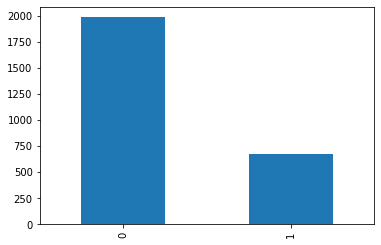

In [20]:
dataset.VIOLENCIA_DE_GENERO = [1 if elem == 'si' else 0 for elem in dataset.VIOLENCIA_DE_GENERO]
dataset.VIOLENCIA_DE_GENERO.value_counts().plot(kind='bar')

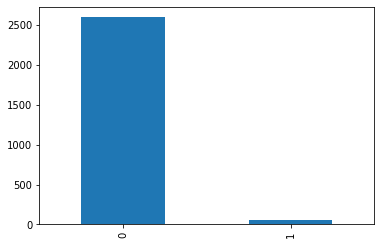

In [21]:
dataset.V_AMB = [1 if elem == 'si' else 0 for elem in dataset.V_AMB]
dataset.V_AMB.value_counts().plot(kind='bar')

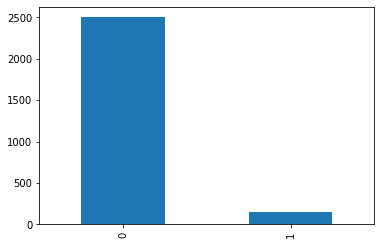

In [22]:
dataset.V_ECON = [1 if elem == 'si' else 0 for elem in dataset.V_ECON]
dataset.V_ECON.value_counts().plot(kind='bar')

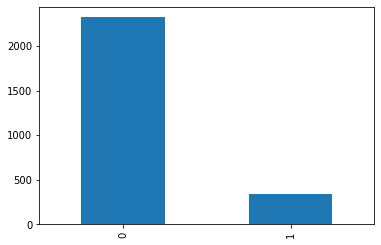

In [23]:
dataset.V_FISICA = [1 if elem == 'si' else 0 for elem in dataset.V_FISICA]
dataset.V_FISICA.value_counts().plot(kind='bar')

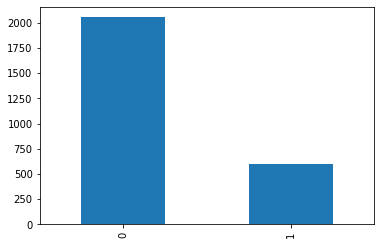

In [24]:
dataset.V_PSIC = [1 if elem == 'si' else 0 for elem in dataset.V_PSIC]
dataset.V_PSIC.value_counts().plot(kind='bar')

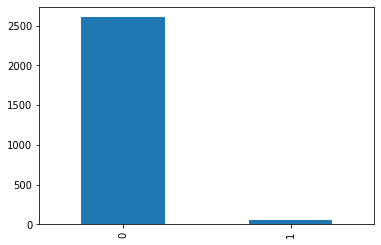

In [25]:
dataset.V_SEX = [1 if elem == 'si' else 0 for elem in dataset.V_SEX]
dataset.V_SEX.value_counts().plot(kind='bar')

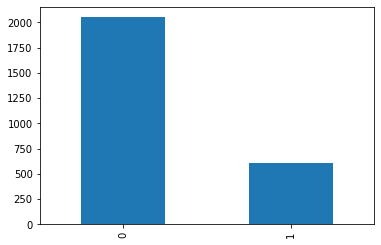

In [26]:
dataset.V_SIMB = [1 if elem == 'si' else 0 for elem in dataset.V_SIMB]
dataset.V_SIMB.value_counts().plot(kind='bar')

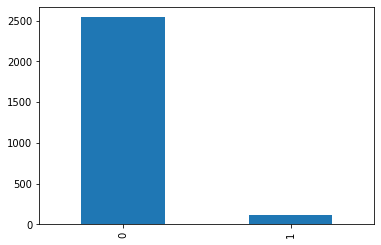

In [27]:
dataset.V_SOC = [1 if elem == 'si' else 0 for elem in dataset.V_SOC]
dataset.V_SOC.value_counts().plot(kind='bar')

### Textos

I then preprocess the corpus. I also chose to lemmatize it because of the small data we have, specially for docs of positive class.

In [28]:
# preprocessing
texts1 = [' '.join(txt.splitlines()) for txt in dataset['TEXTOS']] # remove /n
texts2 = [preprocess_lemm(txt) for txt in texts1] # preprocess. ie. remove punct., lowercase, etc.
texts3 = [filter_stop_words(txt.split()) for txt in texts2] # remove stopwords

In [29]:
dataset.TEXTOS = texts3

### Materia

This is the only other variable I chose (with the exception of text) to be in the model. All others had a lot of missing, or almost all observations with same value, or only a few observations with each value. I grouped together some of the values that had few observations as 'otro' and then create dummy variables for it.

In [30]:
dataset.MATERIA.value_counts()

penal                    1283
contravencional          1097
faltas                    252
allanamiento_autonomo      12
amparo                      8
ejecucion_de_multa          3
habeas_corpus               2
Name: MATERIA, dtype: int64

In [31]:
dataset.MATERIA.replace(['allanamiento_autonomo','amparo','ejecucion_de_multa','habeas_corpus'],
                        ['otro','otro','otro','otro'],inplace=True)

In [32]:
dataset.MATERIA.value_counts()

penal              1283
contravencional    1097
faltas              252
otro                 25
Name: MATERIA, dtype: int64

In [33]:
dummies = ['MATERIA']
dataset = pd.get_dummies(dataset, prefix=dummies, columns=dummies, drop_first=True)

In [34]:
dataset

,TEXTOS,VIOLENCIA_DE_GENERO,V_FISICA,V_PSIC,V_ECON,V_SEX,V_SOC,V_AMB,V_SIMB,MATERIA_faltas,MATERIA_otro,MATERIA_penal
0,u poder judicial ciudad buenos aires fuero pen...,0,0,0,0,0,0,0,0,0,0,1
1,poder judicial ciudad buenos aires fuero penal...,1,0,1,0,0,0,0,1,0,0,1
2,poder judicial ciudad buenos aires fuero penal...,1,1,1,1,0,0,0,1,0,0,0
3,poder judicial ciudad buenos aires fuero penal...,0,0,0,0,0,0,0,0,0,0,0
4,_ li2ll poder judicial ciudad buenos aires fue...,1,0,1,1,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3382,resolucion definitiva extinción acción penal s...,0,0,0,0,0,0,0,0,0,0,1
3383,resolución interlocutoria suspende procesar pr...,0,0,0,0,0,0,0,0,0,0,0
3387,resolución interlocutoria hace lugar medir pro...,1,1,1,0,0,0,0,1,0,0,1
3389,audiencia prisión preventiva art 173 cpp video...,0,0,0,0,0,0,0,0,0,0,1


Finally, I drop duplicate texts not to introduce any bias the model

In [35]:
# drop duplicate text
dataset.drop_duplicates(subset ="TEXTOS",keep = 'first', inplace = True) 
dataset.shape

(2466, 12)

In [2]:
#dataset.to_csv('clean_dataset.csv')
dataset = pd.read_csv('clean_dataset.csv')
dataset.dropna(inplace= True)
dataset.shape

## Tf-idf model

Training occurs in two steps: First, I do a gridsearchCV to find the best parameters for the tf-idf vectorizer (based on recall for VIOLENCIA_DE_GENERO classification) using only the training set, and then with the best parameters I train the actual model and predict on the test set to assert performance.

I trained one model for each target variable, and tackled the inbalance by oversampling (SMOTE) the training set and also using the class_weight parameter of the classifier (giving different weights for different classes).

### Terms associated to each class

In the next fews I train a tfidf vectorizer on the whole dataset to visualize the most important terms for each class (for each variable). This is achieved by comparing the average value of the columns of the tfidf matrix representations for each class.

In [27]:
vect = TfidfVectorizer(min_df = 0.05, 
                         max_df = 0.7, 
                         max_features=1000,
                         use_idf=True)

X_m = vect.fit_transform(dataset.TEXTOS)
y_train = np.array(dataset.VIOLENCIA_DE_GENERO)
n = 20
pickle.dump(vect, open( "./models/vect_most_relevant.sav", "wb"))

In [32]:
get_most_relevant_words2(vect= vect, X_train_m=X_m, dataset=dataset, n = 10, variable='V_FISICA')

array(['alcohol', 'detención', 'transporte', 'sangrar', 'conductor',
       'infractor', '1217', 'lesionar', '451', 'circular'], dtype='<U17')

### VIOLENCIA_DE_GENERO

The models are trained for each variable and saved to disk

% of positive class: 0.2639902676399027
Fitting 5 folds for each of 72 candidates, totalling 360 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   55.4s
[Parallel(n_jobs=-1)]: Done 360 out of 360 | elapsed:  1.9min finished


['episodio' 'sos' 'abordaje' 'caro' 'nene' 'pegar' 'conversaciones' 'ovd'
 'cultura' 'puto' 'doméstica' 'ofavyt' 'cordial' 'violencia' '26485'
 'erradicar' '13944' 'hostigamiento' 'género' 'belem']
              precision    recall  f1-score   support

           0       0.95      0.85      0.90       448
           1       0.69      0.89      0.78       169

    accuracy                           0.86       617
   macro avg       0.82      0.87      0.84       617
weighted avg       0.88      0.86      0.87       617



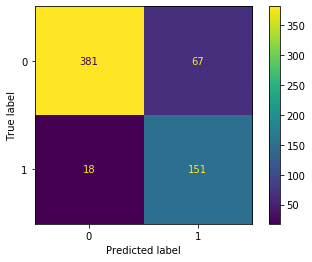

In [61]:
X1 = np.array(dataset.TEXTOS)
X2 = dataset.iloc[:,-3:]
y = np.array(dataset.VIOLENCIA_DE_GENERO)
print("% of positive class: {}".format(y.mean()))

# train test splits
# TEXTS
X_train1, X_test1, y_train, y_test = train_test_split(X1,
                                                    y,
                                                    train_size=.75, 
                                                    random_state=1)

# MATERIA VARIABLE
X_train2, X_test2, y_train, y_test = train_test_split(X2,
                                                    y,
                                                    train_size=.75, 
                                                    random_state=1)

_, score, params = train_tf_idf(X_train1, y_train)

model, vect, y_pred, y_test, X_test, X_train_m = train_tf_idf_materia(X_train1, X_train2, 
                                                     X_test1, X_test2, 
                                                     y_train, y_test, params)

print(get_most_relevant_words(vect, X_train_m, y_train, 20))
print(classification_report(y_test, y_pred))
plot_confusion_matrix(model, X_test, y_test)

# save models
pickle.dump(model, open( "./models/tfidf_genero_model.sav", "wb"))
pickle.dump(vect, open( "./models/tfidf_genero_vect.sav", "wb"))

### V_FISICA

% of positive class: 0.13098134630981345
Fitting 5 folds for each of 72 candidates, totalling 360 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   10.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 360 out of 360 | elapsed:  2.1min finished


['puto' 'lesionar' '80' 'desobediencia' 'acercamiento' 'prevenir'
 'ordinario' '92' 'leve' 'vínculo' '26485' 'erradicar' 'violencia'
 'género' 'doméstico' '89' 'belem' 'agravar' 'ovd' 'respetuoso']
              precision    recall  f1-score   support

           0       0.95      0.86      0.90       524
           1       0.49      0.76      0.59        93

    accuracy                           0.84       617
   macro avg       0.72      0.81      0.75       617
weighted avg       0.88      0.84      0.86       617



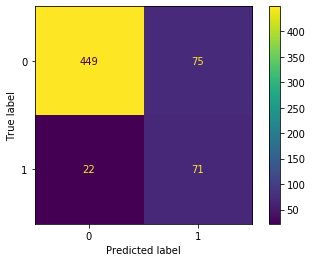

In [62]:
X1 = np.array(dataset.TEXTOS)
X2 = dataset.iloc[:,-3:]
y = np.array(dataset.V_FISICA)
print("% of positive class: {}".format(y.mean()))

# train test splits
# TEXTS
X_train1, X_test1, y_train, y_test = train_test_split(X1,
                                                    y,
                                                    train_size=.75, 
                                                    random_state=1)

# MATERIA VARIABLE
X_train2, X_test2, y_train, y_test = train_test_split(X2,
                                                    y,
                                                    train_size=.75, 
                                                    random_state=1)

_, score, params = train_tf_idf(X_train1, y_train)

model, vect, y_pred, y_test, X_test, X_train_m = train_tf_idf_materia(X_train1, X_train2, 
                                                     X_test1, X_test2, 
                                                     y_train, y_test, params)

print(get_most_relevant_words(vect, X_train_m, y_train, 20))
print(classification_report(y_test, y_pred))
plot_confusion_matrix(model, X_test, y_test)

pickle.dump(model, open( "./models/tfidf_fisica_model.sav", "wb"))
pickle.dump(vect, open( "./models/tfidf_fisica_vect.sav", "wb"))

#model = pickle.load(open("save.p", "rb"))

### V_PSIC

% of positive class: 0.23682076236820762
Fitting 5 folds for each of 72 candidates, totalling 360 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 360 out of 360 | elapsed:  2.1min finished


['caro' 'nene' '149bis' 'hostigar' 'hostigamiento' 'doméstica' 'violencia'
 'género' 'belem' 'conversaciones' 'cordial' 'ofavyt' 'sos' 'ovd' '26485'
 'pegar' 'cultura' 'puto' 'episodio' 'erradicar']
              precision    recall  f1-score   support

           0       0.95      0.85      0.90       460
           1       0.66      0.87      0.75       157

    accuracy                           0.85       617
   macro avg       0.81      0.86      0.82       617
weighted avg       0.88      0.85      0.86       617



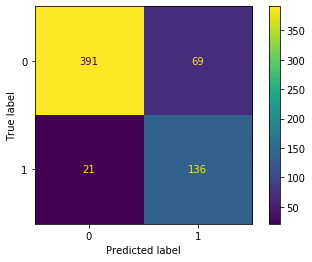

In [63]:
X1 = np.array(dataset.TEXTOS)
X2 = dataset.iloc[:,-3:]
y = np.array(dataset.V_PSIC)
print("% of positive class: {}".format(y.mean()))

# train test splits
# TEXTS
X_train1, X_test1, y_train, y_test = train_test_split(X1,
                                                    y,
                                                    train_size=.75, 
                                                    random_state=1)

# MATERIA VARIABLE
X_train2, X_test2, y_train, y_test = train_test_split(X2,
                                                    y,
                                                    train_size=.75, 
                                                    random_state=1)

_, score, params = train_tf_idf(X_train1, y_train)

model, vect, y_pred, y_test, X_test, X_train_m = train_tf_idf_materia(X_train1, X_train2, 
                                                     X_test1, X_test2, 
                                                     y_train, y_test, params)

print(get_most_relevant_words(vect, X_train_m, y_train, 20))
print(classification_report(y_test, y_pred))
plot_confusion_matrix(model, X_test, y_test)

pickle.dump(model, open( "./models/tfidf_psic_model.sav", "wb"))
pickle.dump(vect, open( "./models/tfidf_psic_vect.sav", "wb"))

#model = pickle.load(open("save.p", "rb"))

### V_ECON

% of positive class: 0.060421735604217354
Fitting 5 folds for each of 72 candidates, totalling 360 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   10.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   58.8s
[Parallel(n_jobs=-1)]: Done 360 out of 360 | elapsed:  2.0min finished


['mes' 'económico' 'alimento' 'tutelar' 'mujer' 'asesoría' '26485'
 'depósito' 'negativo' 'belem' 'familiar' '13944' 'doméstico' 'asesor'
 'indispensable' 'reparación' 'integral' 'cuota' 'violencia' 'asistencia']
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       581
           1       0.28      0.58      0.38        36

    accuracy                           0.89       617
   macro avg       0.63      0.75      0.66       617
weighted avg       0.93      0.89      0.91       617



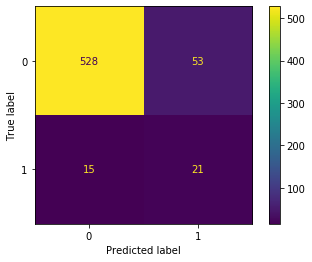

In [64]:
X1 = np.array(dataset.TEXTOS)
X2 = dataset.iloc[:,-3:]
y = np.array(dataset.V_ECON)
print("% of positive class: {}".format(y.mean()))

# train test splits
# TEXTS
X_train1, X_test1, y_train, y_test = train_test_split(X1,
                                                    y,
                                                    train_size=.75, 
                                                    random_state=1)

# MATERIA VARIABLE
X_train2, X_test2, y_train, y_test = train_test_split(X2,
                                                    y,
                                                    train_size=.75, 
                                                    random_state=1)

_, score, params = train_tf_idf(X_train1, y_train)

model, vect, y_pred, y_test, X_test, X_train_m = train_tf_idf_materia(X_train1, X_train2, 
                                                     X_test1, X_test2, 
                                                     y_train, y_test, params)

print(get_most_relevant_words(vect, X_train_m, y_train, 20))
print(classification_report(y_test, y_pred))
plot_confusion_matrix(model, X_test, y_test)

pickle.dump(model, open( "./models/tfidf_econ_model.sav", "wb"))
pickle.dump(vect, open( "./models/tfidf_econ_vect.sav", "wb"))

#model = pickle.load(open("save.p", "rb"))

### V_SEX

% of positive class: 0.021086780210867802
Fitting 5 folds for each of 72 candidates, totalling 360 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    9.6s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   58.2s
[Parallel(n_jobs=-1)]: Done 360 out of 360 | elapsed:  2.0min finished


['amenazar' 'excepción' 'suceso' 'duración' '149' 'ex' 'incompetencia'
 'contexto' 'agravar' 'violencia' 'género' '26485' 'simple' 'acusar'
 'correccional' 'criminal' 'frase' '311' 'dispositivo' 'sexual']
              precision    recall  f1-score   support

           0       0.98      0.91      0.94       596
           1       0.15      0.43      0.22        21

    accuracy                           0.90       617
   macro avg       0.56      0.67      0.58       617
weighted avg       0.95      0.90      0.92       617



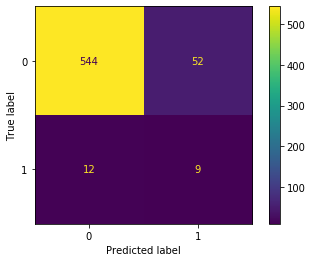

In [65]:
X1 = np.array(dataset.TEXTOS)
X2 = dataset.iloc[:,-3:]
y = np.array(dataset.V_SEX)
print("% of positive class: {}".format(y.mean()))

# train test splits
# TEXTS
X_train1, X_test1, y_train, y_test = train_test_split(X1,
                                                    y,
                                                    train_size=.75, 
                                                    random_state=1)

# MATERIA VARIABLE
X_train2, X_test2, y_train, y_test = train_test_split(X2,
                                                    y,
                                                    train_size=.75, 
                                                    random_state=1)

_, score, params = train_tf_idf(X_train1, y_train)

model, vect, y_pred, y_test, X_test, X_train_m = train_tf_idf_materia(X_train1, X_train2, 
                                                     X_test1, X_test2, 
                                                     y_train, y_test, params)

print(get_most_relevant_words(vect, X_train_m, y_train, 20))
print(classification_report(y_test, y_pred))
plot_confusion_matrix(model, X_test, y_test)

pickle.dump(model, open( "./models/tfidf_sex_model.sav", "wb"))
pickle.dump(vect, open( "./models/tfidf_sex_vect.sav", "wb"))

#model = pickle.load(open("save.p", "rb"))

### V_SOC

% of positive class: 0.047039740470397405
Fitting 5 folds for each of 72 candidates, totalling 360 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   58.8s
[Parallel(n_jobs=-1)]: Done 360 out of 360 | elapsed:  2.0min finished


['defender' 'mujer' 'ir' 'competencia' 'celular' 'mediar' 'denunciar'
 'mantener' 'querer' 'contexto' 'hijo' 'contactar' 'violencia' 'teléfono'
 'amenazar' 'víctima' 'llamar' 'género' 'armar' 'denunciante']
              precision    recall  f1-score   support

           0       0.98      0.87      0.92       586
           1       0.21      0.68      0.32        31

    accuracy                           0.86       617
   macro avg       0.60      0.77      0.62       617
weighted avg       0.94      0.86      0.89       617



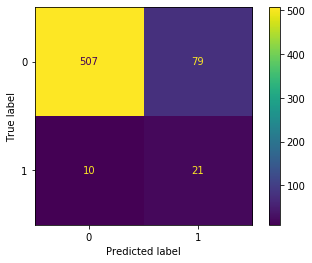

In [66]:
X1 = np.array(dataset.TEXTOS)
X2 = dataset.iloc[:,-3:]
y = np.array(dataset.V_SOC)
print("% of positive class: {}".format(y.mean()))

# train test splits
# TEXTS
X_train1, X_test1, y_train, y_test = train_test_split(X1,
                                                    y,
                                                    train_size=.75, 
                                                    random_state=1)

# MATERIA VARIABLE
X_train2, X_test2, y_train, y_test = train_test_split(X2,
                                                    y,
                                                    train_size=.75, 
                                                    random_state=1)

_, score, params = train_tf_idf(X_train1, y_train)

model, vect, y_pred, y_test, X_test, X_train_m = train_tf_idf_materia(X_train1, X_train2, 
                                                     X_test1, X_test2, 
                                                     y_train, y_test, params)

print(get_most_relevant_words(vect, X_train_m, y_train, 20))
print(classification_report(y_test, y_pred))
plot_confusion_matrix(model, X_test, y_test)

pickle.dump(model, open( "./models/tfidf_soc_model.sav", "wb"))
pickle.dump(vect, open( "./models/tfidf_soc_vect.sav", "wb"))

#model = pickle.load(open("save.p", "rb"))

### V_AMB

% of positive class: 0.023114355231143552
Fitting 5 folds for each of 72 candidates, totalling 360 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    9.8s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   59.0s
[Parallel(n_jobs=-1)]: Done 360 out of 360 | elapsed:  2.0min finished


['vivienda' 'matar' 'corte' 'rta' 'hablar' 'simple' 'materia'
 'jurisdicción' 'audio' 'fuego' 'ex' 'competencia' 'introducir' 'nación'
 'común' 'foto' 'justicia' '149' 'pleno' 'puerta']
              precision    recall  f1-score   support

           0       0.98      0.93      0.95       600
           1       0.12      0.35      0.18        17

    accuracy                           0.91       617
   macro avg       0.55      0.64      0.57       617
weighted avg       0.96      0.91      0.93       617



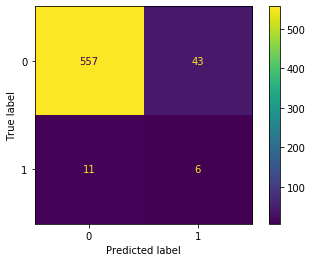

In [67]:
X1 = np.array(dataset.TEXTOS)
X2 = dataset.iloc[:,-3:]
y = np.array(dataset.V_AMB)
print("% of positive class: {}".format(y.mean()))

# train test splits
# TEXTS
X_train1, X_test1, y_train, y_test = train_test_split(X1,
                                                    y,
                                                    train_size=.75, 
                                                    random_state=1)

# MATERIA VARIABLE
X_train2, X_test2, y_train, y_test = train_test_split(X2,
                                                    y,
                                                    train_size=.75, 
                                                    random_state=1)

_, score, params = train_tf_idf(X_train1, y_train)

model, vect, y_pred, y_test, X_test, X_train_m = train_tf_idf_materia(X_train1, X_train2, 
                                                     X_test1, X_test2, 
                                                     y_train, y_test, params)

print(get_most_relevant_words(vect, X_train_m, y_train, 20))
print(classification_report(y_test, y_pred))
plot_confusion_matrix(model, X_test, y_test)

pickle.dump(model, open( "./models/tfidf_amb_model.sav", "wb"))
pickle.dump(vect, open( "./models/tfidf_amb_vect.sav", "wb"))

#model = pickle.load(open("save.p", "rb"))

### V_SIMB

% of positive class: 0.23803730738037307
Fitting 5 folds for each of 72 candidates, totalling 360 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    9.8s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   58.6s
[Parallel(n_jobs=-1)]: Done 360 out of 360 | elapsed:  2.0min finished


['relatar' 'contactar' 'denunciante' 'querer' '149' 'violencia' 'ex'
 'amenazar' 'contexto' 'común' 'agravar' 'mensaje' 'víctima' 'damnificar'
 'parejo' 'frase' 'matar' 'género' 'mujer' '26485']
              precision    recall  f1-score   support

           0       0.95      0.85      0.90       461
           1       0.66      0.87      0.75       156

    accuracy                           0.86       617
   macro avg       0.81      0.86      0.83       617
weighted avg       0.88      0.86      0.86       617



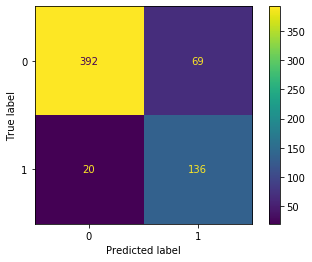

In [68]:
X1 = np.array(dataset.TEXTOS)
X2 = dataset.iloc[:,-3:]
y = np.array(dataset.V_SIMB)
print("% of positive class: {}".format(y.mean()))

# train test splits
# TEXTS
X_train1, X_test1, y_train, y_test = train_test_split(X1,
                                                    y,
                                                    train_size=.75, 
                                                    random_state=1)

# MATERIA VARIABLE
X_train2, X_test2, y_train, y_test = train_test_split(X2,
                                                    y,
                                                    train_size=.75, 
                                                    random_state=1)

_, score, params = train_tf_idf(X_train1, y_train)

model, vect, y_pred, y_test, X_test, X_train_m = train_tf_idf_materia(X_train1, X_train2, 
                                                     X_test1, X_test2, 
                                                     y_train, y_test, params)

print(get_most_relevant_words(vect, X_train_m, y_train, 20))
print(classification_report(y_test, y_pred))
plot_confusion_matrix(model, X_test, y_test)

pickle.dump(model, open( "./models/tfidf_simb_model.sav", "wb"))
pickle.dump(vect, open( "./models/tfidf_simb_vect.sav", "wb"))

#model = pickle.load(open("save.p", "rb"))

## Doc2Vec

First, I gridsearchCV Doc2vec embeddings parameters to classificate VIOLENCIA_DE_GENERO using a train set only. Then I used the best parameters to train a doc2vec embedding on the whole corpus and use it on the classification models.

In [3]:
# gridsearchCV classification problem for VIOLENCIA_DE_GENERO using only training set. get best params
X1 = dataset.TEXTOS
X2 = dataset.iloc[:,-3:]
y = dataset.VIOLENCIA_DE_GENERO

X_train1, X_test1, y_train, y_test = train_test_split(X1,
                                                    y,
                                                    train_size=.75, 
                                                    random_state=1)

X_train2, X_test2, y_train, y_test = train_test_split(X2,
                                                    y,
                                                    train_size=.75, 
                                                    random_state=1)

res, params = grid_search_doc2vec(X_train1, X_train2, y_train)
print(params)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


{'size': 1500.0, 'count': 1.0, 'dm': 0.0}


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.6s finished


In [16]:
# train embeddings on whole corpus using previous cell params
docs_token = []
for doc in X1:
    try:
        docs_token.append(doc.split())
    except:
        docs_token.append(None)

docs_token = [doc for doc in docs_token if doc is not None]
documents = [doc2vec.TaggedDocument(doc, [i]) for i, doc in enumerate(docs_token)]  

# take vectorizer params from gridsearch_cv and define it
size = params['size']
count = params['count']
dm = params['dm']

# define model, vocab and train it
model = doc2vec.Doc2Vec(vector_size=size, min_count=count,
                        epochs=40, workers = cores-1, dm= dm)

model.build_vocab(documents)
model.train(documents, total_examples=model.corpus_count, epochs=model.epochs)

pickle.dump(model, open( "./models/dov2vec_embbed.sav", "wb"))

model.delete_temporary_training_data(keep_doctags_vectors=True, keep_inference=True)

### VIOLENCIA_DE_GENERO

              precision    recall  f1-score   support

           0       0.93      0.94      0.93       448
           1       0.84      0.81      0.82       169

    accuracy                           0.90       617
   macro avg       0.88      0.88      0.88       617
weighted avg       0.90      0.90      0.90       617



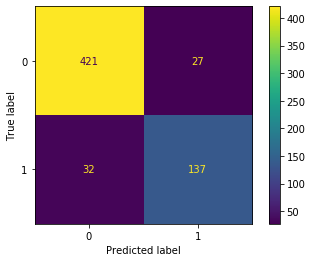

In [4]:
X1 = dataset.TEXTOS
X1.fillna("",inplace=True)
X2 = dataset.iloc[:,-3:]
y = dataset.VIOLENCIA_DE_GENERO

doc2vec_embedd = pickle.load(open("./models/dov2vec_embbed.sav", "rb"))
lrmodel, ypred, X_test, y_test = train_doc2vec_classifier(X1, X2, y, doc2vec_embedd)

print(classification_report(y_test, ypred))
plot_confusion_matrix(lrmodel, X_test, y_test)

pickle.dump(lrmodel, open( "./models/doc2vec_genero_model.sav", "wb"))

### V_FISICA

              precision    recall  f1-score   support

           0       0.92      0.93      0.92       524
           1       0.56      0.53      0.54        93

    accuracy                           0.87       617
   macro avg       0.74      0.73      0.73       617
weighted avg       0.86      0.87      0.86       617



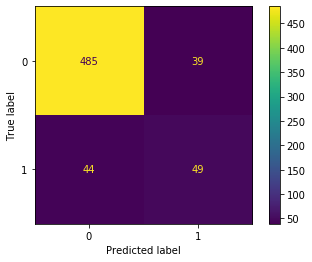

In [5]:
X1 = dataset.TEXTOS
X1.fillna("",inplace=True)
X2 = dataset.iloc[:,-3:]
y = dataset.V_FISICA

doc2vec_embedd = pickle.load(open("./models/dov2vec_embbed.sav", "rb"))
lrmodel, ypred, X_test, y_test = train_doc2vec_classifier(X1, X2, y, doc2vec_embedd)

print(classification_report(y_test, ypred))
plot_confusion_matrix(lrmodel, X_test, y_test)

pickle.dump(lrmodel, open( "./models/doc2vec_fisica_model.sav", "wb"))

### V_PSIC

              precision    recall  f1-score   support

           0       0.92      0.91      0.91       460
           1       0.74      0.78      0.76       157

    accuracy                           0.87       617
   macro avg       0.83      0.84      0.84       617
weighted avg       0.88      0.87      0.87       617



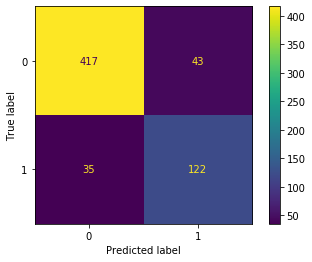

In [6]:
X1 = dataset.TEXTOS
X1.fillna("",inplace=True)
X2 = dataset.iloc[:,-3:]
y = dataset.V_PSIC

doc2vec_embedd = pickle.load(open("./models/dov2vec_embbed.sav", "rb"))
lrmodel, ypred, X_test, y_test = train_doc2vec_classifier(X1, X2, y, doc2vec_embedd)

print(classification_report(y_test, ypred))
plot_confusion_matrix(lrmodel, X_test, y_test)

pickle.dump(lrmodel, open( "./models/doc2vec_psic_model.sav", "wb"))

### V_ECON 

              precision    recall  f1-score   support

           0       0.96      0.93      0.95       581
           1       0.25      0.36      0.30        36

    accuracy                           0.90       617
   macro avg       0.61      0.65      0.62       617
weighted avg       0.92      0.90      0.91       617



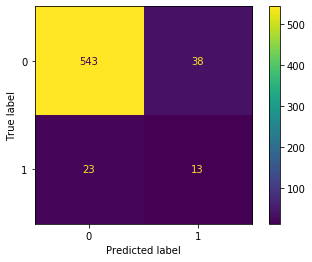

In [7]:
X1 = dataset.TEXTOS
X1.fillna("",inplace=True)
X2 = dataset.iloc[:,-3:]
y = dataset.V_ECON

doc2vec_embedd = pickle.load(open("./models/dov2vec_embbed.sav", "rb"))
lrmodel, ypred, X_test, y_test = train_doc2vec_classifier(X1, X2, y, doc2vec_embedd)

print(classification_report(y_test, ypred))
plot_confusion_matrix(lrmodel, X_test, y_test)

pickle.dump(lrmodel, open( "./models/doc2vec_econ_model.sav", "wb"))

### V_SEX

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       596
           1       0.50      0.24      0.32        21

    accuracy                           0.97       617
   macro avg       0.74      0.61      0.65       617
weighted avg       0.96      0.97      0.96       617



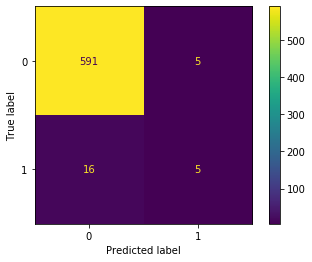

In [8]:
X1 = dataset.TEXTOS
X1.fillna("",inplace=True)
X2 = dataset.iloc[:,-3:]
y = dataset.V_SEX

doc2vec_embedd = pickle.load(open("./models/dov2vec_embbed.sav", "rb"))
lrmodel, ypred, X_test, y_test = train_doc2vec_classifier(X1, X2, y, doc2vec_embedd)

print(classification_report(y_test, ypred))
plot_confusion_matrix(lrmodel, X_test, y_test)

pickle.dump(lrmodel, open( "./models/doc2vec_sex_model.sav", "wb"))

### V_SOC

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       586
           1       0.42      0.52      0.46        31

    accuracy                           0.94       617
   macro avg       0.70      0.74      0.72       617
weighted avg       0.95      0.94      0.94       617



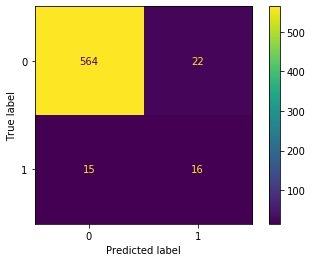

In [9]:
X1 = dataset.TEXTOS
X1.fillna("",inplace=True)
X2 = dataset.iloc[:,-3:]
y = dataset.V_SOC

doc2vec_embedd = pickle.load(open("./models/dov2vec_embbed.sav", "rb"))
lrmodel, ypred, X_test, y_test = train_doc2vec_classifier(X1, X2, y, doc2vec_embedd)

print(classification_report(y_test, ypred))
plot_confusion_matrix(lrmodel, X_test, y_test)

pickle.dump(lrmodel, open( "./models/doc2vec_soc_model.sav", "wb"))

### V_AMB

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       600
           1       0.20      0.24      0.22        17

    accuracy                           0.95       617
   macro avg       0.59      0.60      0.60       617
weighted avg       0.96      0.95      0.95       617



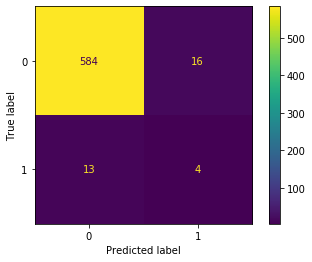

In [10]:
X1 = dataset.TEXTOS
X1.fillna("",inplace=True)
X2 = dataset.iloc[:,-3:]
y = dataset.V_AMB

doc2vec_embedd = pickle.load(open("./models/dov2vec_embbed.sav", "rb"))
lrmodel, ypred, X_test, y_test = train_doc2vec_classifier(X1, X2, y, doc2vec_embedd)

print(classification_report(y_test, ypred))
plot_confusion_matrix(lrmodel, X_test, y_test)

pickle.dump(lrmodel, open( "./models/doc2vec_amb_model.sav", "wb"))

### V_SIMB

              precision    recall  f1-score   support

           0       0.92      0.90      0.91       461
           1       0.72      0.78      0.74       156

    accuracy                           0.87       617
   macro avg       0.82      0.84      0.83       617
weighted avg       0.87      0.87      0.87       617



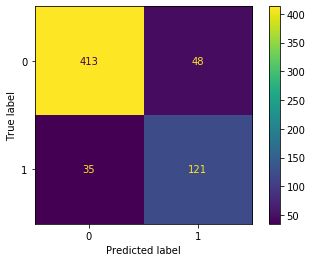

In [11]:
X1 = dataset.TEXTOS
X1.fillna("",inplace=True)
X2 = dataset.iloc[:,-3:]
y = dataset.V_SIMB

doc2vec_embedd = pickle.load(open("./models/dov2vec_embbed.sav", "rb"))
lrmodel, ypred, X_test, y_test = train_doc2vec_classifier(X1, X2, y, doc2vec_embedd)

print(classification_report(y_test, ypred))
plot_confusion_matrix(lrmodel, X_test, y_test)

pickle.dump(lrmodel, open( "./models/doc2vec_simb_model.sav", "wb"))